In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
#All daily series are resampled to weekly frequency using week-ending Friday values, taking the last available observation within each week.

sp500 = pd.read_csv("sp500.csv", parse_dates=["Date"])
sp500 = sp500.set_index("Date").sort_index()

In [5]:
sp500_weekly = (
    sp500
    .resample("W-FRI")
    .last()
)

In [6]:
print(sp500_weekly.head()) #sanity check 1

             Adj Close       Close        High         Low        Open  \
Date                                                                     
1994-01-07  469.899994  469.899994  470.260010  467.029999  467.089996   
1994-01-14  474.910004  474.910004  475.320007  472.500000  472.500000   
1994-01-21  474.720001  474.720001  475.559998  473.720001  474.980011   
1994-01-28  478.700012  478.700012  479.750000  477.049988  477.049988   
1994-02-04  469.809998  469.809998  481.019989  469.279999  480.679993   

               Volume  
Date                   
1994-01-07  324920000  
1994-01-14  304920000  
1994-01-21  346350000  
1994-01-28  313140000  
1994-02-04  378380000  


In [7]:
print(sp500_weekly.index.is_monotonic_increasing) # sanity check 2

True


In [8]:
sp500_weekly.to_csv("sp500_weekly.csv")

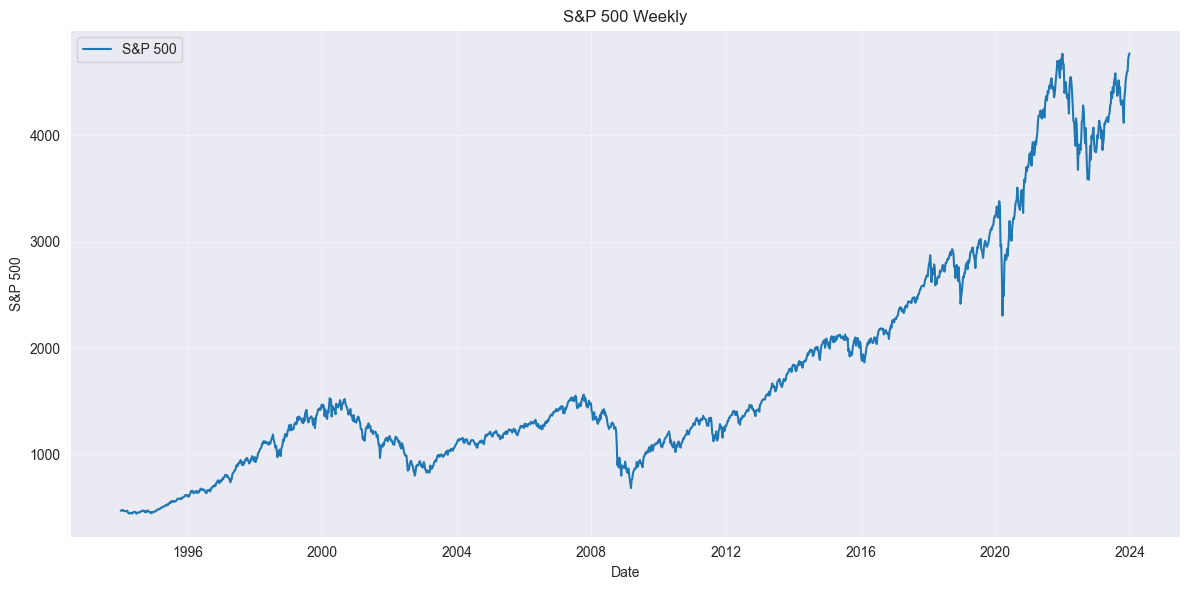

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(sp500_weekly.index, sp500_weekly["Close"], label="S&P 500", color="tab:blue")
plt.xlabel("Date")
plt.ylabel("S&P 500")
plt.title("S&P 500 Weekly")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()